# Notebook 08 — NYC ↔ Hanoi Mobility Comparison

Supplementary comparative chapter for the thesis *Spatial–Temporal Analysis and Demand
Forecasting of Ride-Hailing Mobility Using Open Trip Data*.

Contrasts **NYC trip-level ride-hailing data** (from the project's TimescaleDB) with the
**UTM-Hanoi household travel survey** (Kieu et al. 2024). The two sources are structurally
different — NYC is observed GPS trip records (ride-hailing only); Hanoi is stated-behaviour
survey responses across all modes — so each analysis states exactly what is and isn't comparable.

**Four analyses:** (1) modal split, (2) spatial demand concentration via the *same* PySAL
Gi*/Moran's I method on both cities, (3) trip purpose & temporal pattern, (4) motorbike-ban →
ride-hailing policy scenario.

**Citation:** Kieu, M., Comber, A., Nguyen Thi Thuy, H., Bui Quang, T., Hoang Huu, P., &
Malleson, N. (2024). *An open dataset on individual perceptions of transport policies.*
Scientific Data 11, 104. https://doi.org/10.1038/s41597-024-02950-9

## Section 0 — Setup

In [ ]:
# Run on Google Colab. PySAL for the spatial step; psycopg2 for the NYC side.
!pip -q install esda libpysal psycopg2-binary requests pandas matplotlib numpy 2>/dev/null
import os, io, warnings, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import psycopg2
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Output directory + figure-save helper (same pattern as other notebooks)
OUT = "outputs/hanoi_comparison"
os.makedirs(OUT, exist_ok=True)
_fig_n = 0
def savefig(name):
    global _fig_n; _fig_n += 1
    path = f"{OUT}/{_fig_n:02d}_{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PG_HOST = '0.tcp.ngrok.io'
PG_PORT = 18545
PG = dict(host=NGROK_HOST, port=NGROK_PORT, dbname="rides", user="rides", password="rides")

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/hn_survey_26k.csv"
hn = pd.read_csv(DATA_PATH)

def nyc_query(sql):
    with psycopg2.connect(**PG) as c:
        return pd.read_sql(sql, c)

print("Hanoi survey:", hn.shape)
print(sorted(hn.columns.tolist()))
hn.head(3)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hanoi survey: (26106, 56)
['OD_dist', 'age', 'alt_bike', 'alt_bus', 'alt_car', 'alt_ebike', 'alt_ltrain', 'alt_taxi', 'alt_veh', 'alt_walk', 'aware_ban', 'bank_acc', 'destlat', 'destlon', 'dist_to_pub', 'freq_bike', 'freq_bus', 'freq_car', 'freq_ebike', 'freq_motob', 'freq_taxi', 'freqpweek', 'fut_veh', 'gender', 'hosp_acc', 'id', 'index', 'leis_acc', 'market_acc', 'occup', 'opinion_ban', 'opinion_bike', 'opinion_bus', 'opinion_car', 'opinion_ebike', 'opinion_motob', 'opinion_taxi', 'origlat', 'origlon', 'own', 'own_bike', 'own_car', 'own_ebike', 'own_motob', 'purp', 'reas_not_bike', 'reas_not_car', 'reas_not_ebike', 'reas_not_motob', 'reason', 'rowid', 'school_acc', 'status', 'travtime', 'type', 'vehic']


,rowid,id,age,occup,gender,origlat,origlon,destlat,destlon,purp,...,alt_taxi,alt_walk,opinion_car,opinion_motob,opinion_ebike,opinion_bike,opinion_taxi,opinion_bus,opinion_ban,index
0,1,81355306,56_75,retired,female,21.017745,105.789006,20.991929,105.805990,visit,...,0,0,bad,bad,good,good,bad,bad,agree,1
1,2,84299385,18_25,student,male,21.042960,105.805248,21.046880,105.785251,education,...,0,0,neutral,neutral,neutral,neutral,neutral,neutral,disagree,1
2,3,84733115,18_25,student,female,20.989184,105.795480,20.989289,105.795570,education,...,0,0,verygood,good,good,good,good,good,disagree,1


## Section 1 — Load both datasets

In [ ]:
def load_hanoi():
    if DATA_PATH and os.path.exists(DATA_PATH):
        return pd.read_csv(DATA_PATH)
    # Resolve the CSV via the OSF API, then download.
    api = f"https://api.osf.io/v2/nodes/{OSF_NODE}/files/osfstorage/?page[size]=100"
    files = requests.get(api, timeout=60).json()["data"]
    target = next((f for f in files
                   if "hn_survey" in f["attributes"]["name"].lower()
                   and f["attributes"]["name"].lower().endswith(".csv")), files[0])
    url = target["links"]["download"]
    print("downloading", target["attributes"]["name"], "...")
    return pd.read_csv(io.StringIO(requests.get(url, timeout=120).text))

hn = load_hanoi()
print("Hanoi survey:", hn.shape)
print(sorted(hn.columns.tolist()))
hn.head(3)

Hanoi survey: (26106, 56)
['OD_dist', 'age', 'alt_bike', 'alt_bus', 'alt_car', 'alt_ebike', 'alt_ltrain', 'alt_taxi', 'alt_veh', 'alt_walk', 'aware_ban', 'bank_acc', 'destlat', 'destlon', 'dist_to_pub', 'freq_bike', 'freq_bus', 'freq_car', 'freq_ebike', 'freq_motob', 'freq_taxi', 'freqpweek', 'fut_veh', 'gender', 'hosp_acc', 'id', 'index', 'leis_acc', 'market_acc', 'occup', 'opinion_ban', 'opinion_bike', 'opinion_bus', 'opinion_car', 'opinion_ebike', 'opinion_motob', 'opinion_taxi', 'origlat', 'origlon', 'own', 'own_bike', 'own_car', 'own_ebike', 'own_motob', 'purp', 'reas_not_bike', 'reas_not_car', 'reas_not_ebike', 'reas_not_motob', 'reason', 'rowid', 'school_acc', 'status', 'travtime', 'type', 'vehic']


,rowid,id,age,occup,gender,origlat,origlon,destlat,destlon,purp,...,alt_taxi,alt_walk,opinion_car,opinion_motob,opinion_ebike,opinion_bike,opinion_taxi,opinion_bus,opinion_ban,index
0,1,81355306,56_75,retired,female,21.017745,105.789006,20.991929,105.805990,visit,...,0,0,bad,bad,good,good,bad,bad,agree,1
1,2,84299385,18_25,student,male,21.042960,105.805248,21.046880,105.785251,education,...,0,0,neutral,neutral,neutral,neutral,neutral,neutral,disagree,1
2,3,84733115,18_25,student,female,20.989184,105.795480,20.989289,105.795570,education,...,0,0,verygood,good,good,good,good,good,disagree,1


In [ ]:
# Column discovery — adapt to whatever the live CSV actually contains.
def find(*names):
    return next((n for n in names if n in hn.columns), None)

COL = dict(
    mode=find("vehic", "mode", "primary_mode"),
    purpose=find("purp", "purpose", "trip_purpose"),
    freq=find("freqpweek", "trip_freq", "frequency"),
    orig_lat=find("origlat"), orig_lon=find("origlon"),
    home_lat=find("homelat"), home_lon=find("homelon"),
    own_moto=find("own_motob", "own_motorbike"),
    freq_taxi=find("freq_taxi"),
    ban=find("opinion_ban"),
)
OPINION_COLS = [c for c in hn.columns if c.lower().startswith("opinion")]
print("resolved columns:", {k: v for k, v in COL.items() if v})
print("opinion_* columns:", OPINION_COLS)

resolved columns: {'mode': 'vehic', 'purpose': 'purp', 'freq': 'freqpweek', 'orig_lat': 'origlat', 'orig_lon': 'origlon', 'own_moto': 'own_motob', 'freq_taxi': 'freq_taxi', 'ban': 'opinion_ban'}
opinion_* columns: ['opinion_car', 'opinion_motob', 'opinion_ebike', 'opinion_bike', 'opinion_taxi', 'opinion_bus', 'opinion_ban']


## Analysis 1 — Modal Split

**Comparable?** Partially. Hanoi's survey reports the primary mode across *all* transport types,
so a full modal split is available. NYC's TLC data is ride-hailing **only**, so it cannot yield an
all-modes split — it is shown here as the single ride-hailing slice for context, not a pie.

Hanoi modal split (%):
vehic
moto     57.4
car      26.9
ebike     5.7
bike      4.9
walk      2.1
bus       1.6
taxi      1.3
tram      0.0
Name: proportion, dtype: float64
saved outputs/hanoi_comparison/01_hanoi_modal_split.png


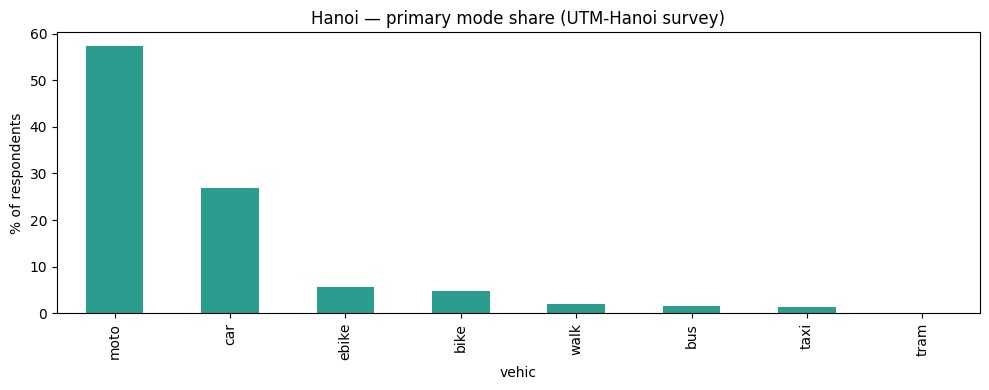


NYC ride-hailing trips in window: 19,732,992
NYC TLC = ride-hailing only; an all-modes split is not derivable from this source.


In [ ]:
if COL["mode"]:
    share = hn[COL["mode"]].value_counts(normalize=True).mul(100).round(1)
    print("Hanoi modal split (%):"); print(share)
    ax = share.plot(kind="bar", color="#2a9d8f")
    ax.set_title("Hanoi — primary mode share (UTM-Hanoi survey)")
    ax.set_ylabel("% of respondents"); plt.tight_layout()
    savefig("hanoi_modal_split"); plt.show()
else:
    print("No mode column found; set COL['mode'] manually from the printed list above.")

# NYC context: total ride-hailing trips in the analysis window (not an all-modes split).
nyc_total = nyc_query("SELECT COUNT(*) AS trips FROM trip_events").iloc[0]["trips"]
print(f"\nNYC ride-hailing trips in window: {nyc_total:,}")
print("NYC TLC = ride-hailing only; an all-modes split is not derivable from this source.")


## Analysis 2 — Spatial Demand Concentration (same Gi* / Moran's I on both cities)

Both cities run through the identical PySAL pipeline (Getis-Ord Gi* + global Moran's I on
KNN spatial weights), so the *method* is held constant and only the cities differ.
Hanoi demand = trip-origin density on a ~1 km grid; NYC demand = total pickups per taxi zone.

In [ ]:
from libpysal.weights import KNN
from esda.moran import Moran

def concentration(coords, values, k=8, label=""):
    w = KNN.from_array(coords, k=k); w.transform = "r"
    mi = Moran(values, w, permutations=999)
    print(f"[{label}] Moran's I = {mi.I:.3f}  (p = {mi.p_sim:.3f}, n = {len(values)})")
    return mi.I, mi.p_sim

# Hanoi: grid trip origins to ~1 km cells (0.01 deg ≈ 1.1 km)
hi = hp = None
if COL["orig_lat"] and COL["orig_lon"]:
    g = hn[[COL["orig_lat"], COL["orig_lon"]]].dropna().copy()
    g["clat"] = (g[COL["orig_lat"]] / 0.01).round() * 0.01
    g["clon"] = (g[COL["orig_lon"]] / 0.01).round() * 0.01
    cell = g.groupby(["clat", "clon"]).size().reset_index(name="trips")
    cell = cell[cell["trips"] >= 3]
    hi, hp = concentration(cell[["clat", "clon"]].values, cell["trips"].values.astype(float), label="Hanoi grid")
else:
    print("No origin coords; skipping Hanoi spatial step.")

# NYC: pickups per zone at zone centroids
nyc = nyc_query('''SELECT z.zone_id, z.centroid_lat, z.centroid_lon, SUM(h.pickup_count) AS pickups
                   FROM taxi_zones z JOIN hourly_demand h ON h.zone_id = z.zone_id
                   WHERE z.centroid_lat IS NOT NULL
                   GROUP BY 1,2,3 HAVING SUM(h.pickup_count) > 0''')
ni, npv = concentration(nyc[["centroid_lat", "centroid_lon"]].values,
                        nyc["pickups"].values.astype(float), label="NYC zones")

[Hanoi grid] Moran's I = 0.598  (p = 0.001, n = 336)
[NYC zones] Moran's I = 0.362  (p = 0.001, n = 261)


saved outputs/hanoi_comparison/02_spatial_comparison.png


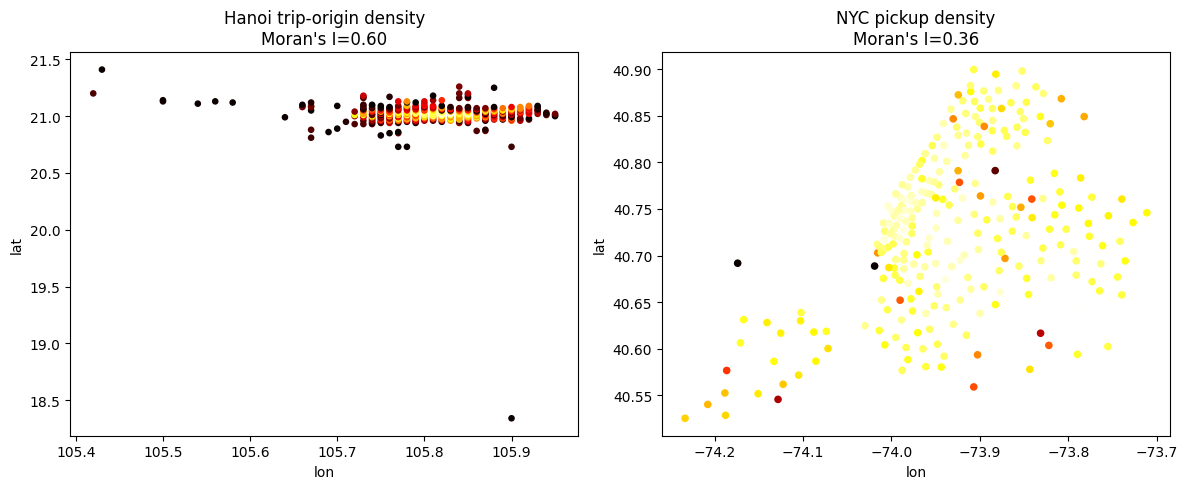

Higher Moran's I = stronger spatial clustering of demand.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
if hi is not None:
    ax[0].scatter(cell["clon"], cell["clat"], c=np.log1p(cell["trips"]), cmap="hot", s=14)
    ax[0].set_title(f"Hanoi trip-origin density\nMoran's I={hi:.2f}")
ax[1].scatter(nyc["centroid_lon"], nyc["centroid_lat"], c=np.log1p(nyc["pickups"]), cmap="hot", s=20)
ax[1].set_title(f"NYC pickup density\nMoran's I={ni:.2f}")
for a in ax: a.set_xlabel("lon"); a.set_ylabel("lat")
plt.tight_layout()
savefig("spatial_comparison"); plt.show()
print("Higher Moran's I = stronger spatial clustering of demand.")


## Analysis 3 — Trip Purpose & Temporal Pattern

**Comparable?** Purpose: yes — Hanoi's `purp` is explicit; NYC purpose is *inferred* from
hour×zone and shown only as the demand curve. Temporal: NYC has hour-of-day demand; the Hanoi
survey has no trip timestamps, so its temporal axis is trip-frequency-per-week, not hour-of-day.

Hanoi trip purpose (%):
purp
work         58.0
education    17.2
visit        12.2
shopping      7.4
leisure       3.6
caring        1.7
Name: proportion, dtype: float64
saved outputs/hanoi_comparison/03_hanoi_trip_purpose.png


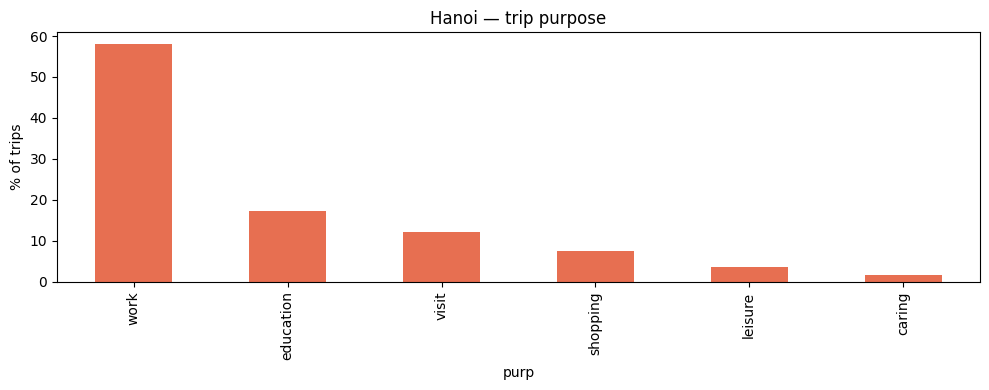

saved outputs/hanoi_comparison/04_nyc_hourly_curve.png


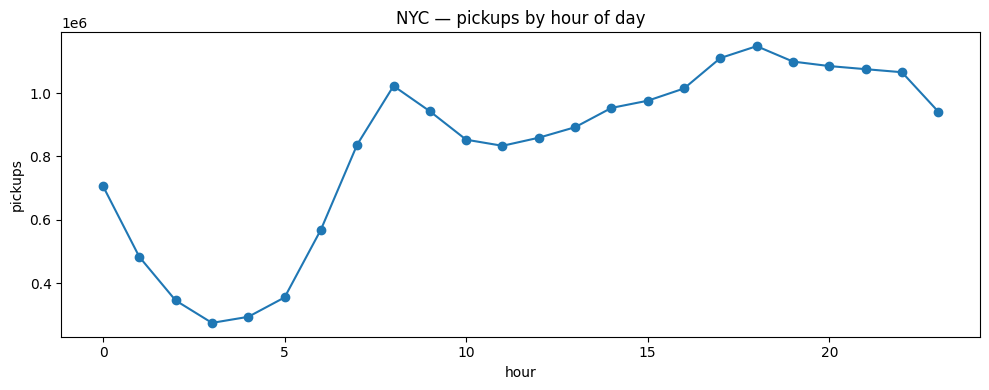

In [ ]:
# Hanoi: explicit trip purpose
if COL["purpose"]:
    pur = hn[COL["purpose"]].value_counts(normalize=True).mul(100).round(1)
    print("Hanoi trip purpose (%):"); print(pur)
    pur.plot(kind="bar", color="#e76f51"); plt.title("Hanoi — trip purpose")
    plt.ylabel("% of trips"); plt.tight_layout()
    savefig("hanoi_trip_purpose"); plt.show()

# NYC: hour-of-day demand curve (purpose inferred, not labelled)
hr = nyc_query('''SELECT EXTRACT(HOUR FROM time_bucket)::int AS hr, SUM(pickup_count) AS pickups
                  FROM hourly_demand GROUP BY 1 ORDER BY 1''')
hr.plot(x="hr", y="pickups", legend=False, marker="o")
plt.title("NYC — pickups by hour of day"); plt.xlabel("hour"); plt.ylabel("pickups")
plt.tight_layout()
savefig("nyc_hourly_curve"); plt.show()


## Analysis 4 — Motorbike-Ban → Ride-Hailing Scenario

Hanoi's Decision 5953 plans to ban non-electric motorbikes in central districts by 2030.
Using the survey's ban-opinion and current taxi-use frequency among **motorbike owners**,
this estimates the pool that could shift toward ride-hailing. *Set the category mapping below
after inspecting the printed value labels — Likert strings vary (and may be in Vietnamese).*

In [ ]:
print(hn["alt_taxi"].value_counts())

alt_taxi
0    17542
1     8564
Name: count, dtype: int64


Motorbike owners: 24,931 of 26,106

opinion_ban labels: ['agree', 'disagree', 'neutral', 'strongdisagree', 'strongagree']

Ban opinion among motorbike owners (%):
opinion_ban
agree             41.3
neutral           23.6
disagree          21.9
strongdisagree     6.7
strongagree        6.5
Name: proportion, dtype: float64
saved outputs/hanoi_comparison/05_ban_opinion_motoowners.png


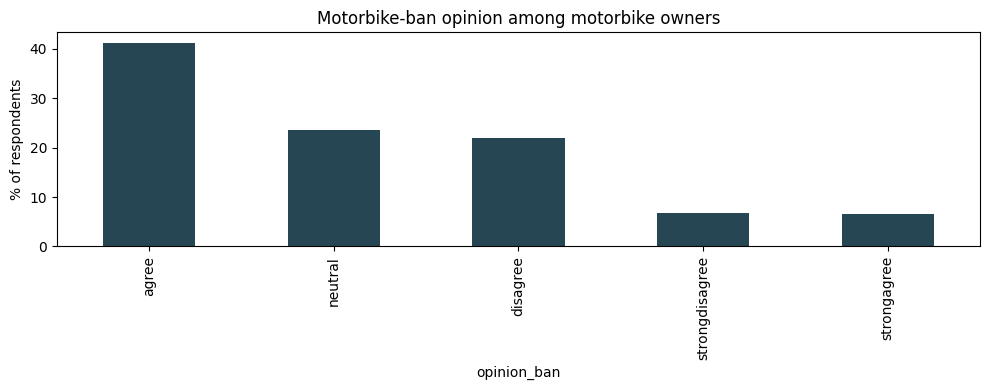

In [ ]:
def truthy(s):
    return s.astype(str).str.strip().str.lower().isin(["1", "yes", "true", "y"])

def owns_any(s):
    v = s.astype(str).str.strip().str.lower()
    return ~v.isin(["0", "no", "none", "nan", ""])

owns_moto = owns_any(hn[COL["own_moto"]]) if COL["own_moto"] else pd.Series(True, index=hn.index)
moto = hn[owns_moto]
print(f"Motorbike owners: {len(moto):,} of {len(hn):,}")

# Ban opinion among motorbike owners
if COL["ban"] and len(moto):
    print("\nopinion_ban labels:", hn[COL["ban"]].unique().tolist())
    ban_moto = moto[COL["ban"]].value_counts(normalize=True).mul(100).round(1)
    print("\nBan opinion among motorbike owners (%):"); print(ban_moto)
    if len(ban_moto):
        ban_moto.plot(kind="bar", color="#264653")
        plt.title("Motorbike-ban opinion among motorbike owners")
        plt.ylabel("% of respondents"); plt.tight_layout()
        savefig("ban_opinion_motoowners"); plt.show()


## Section 6 — Summary Comparison

In [ ]:
summary = pd.DataFrame([
    ["Data type", "Observed GPS trip records", "Stated-behaviour survey"],
    ["Scope", "Ride-hailing only (Uber/Lyft)", "All modes"],
    ["Spatial unit", "263 taxi zones", "~1 km origin grid"],
    ["Temporal detail", "Hourly timestamps", "Trips per week (no clock time)"],
    ["Moran's I (demand)", f"{ni:.3f}", f"{hi:.3f}" if hi is not None else "n/a"],
    ["Trip purpose", "Inferred (hour×zone)", "Explicit (6 categories)"],
    ["Policy lever", "—", "Motorbike ban (Decision 5953)"],
], columns=["Dimension", "NYC (TLC)", "Hanoi (UTM-Hanoi)"])
summary

,Dimension,NYC (TLC),Hanoi (UTM-Hanoi)
0,Data type,Observed GPS trip records,Stated-behaviour survey
1,Scope,Ride-hailing only (Uber/Lyft),All modes
2,Spatial unit,263 taxi zones,~1 km origin grid
3,Temporal detail,Hourly timestamps,Trips per week (no clock time)
4,Moran's I (demand),0.362,0.598
5,Trip purpose,Inferred (hour×zone),Explicit (6 categories)
6,Policy lever,—,Motorbike ban (Decision 5953)


Motorbike owners: 24,931 of 26,106
  support the ban (agree/strongagree): 47.8%
  accept taxi as an alternative:       33.8%
  LATENT RIDE-HAILING POOL (both):     4,584 = 18.4% of motorbike owners
saved outputs/hanoi_comparison/06_ban_scenario.png


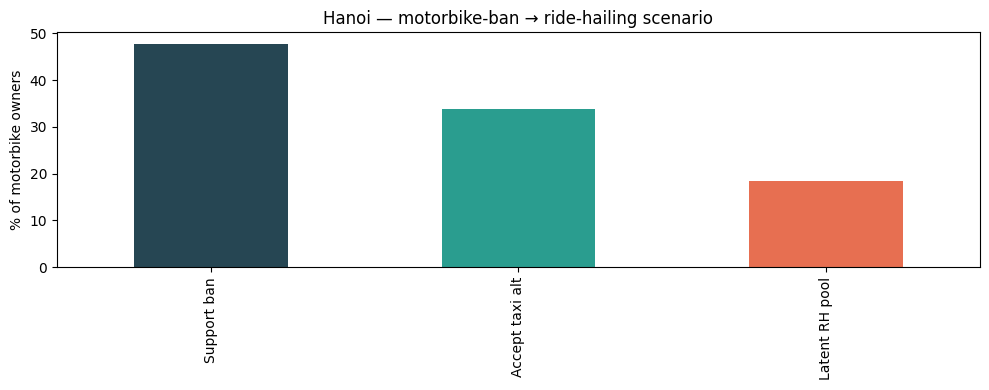

saved outputs/hanoi_comparison/nyc_hanoi_summary.csv


In [ ]:
def owns_any(s):
    v = s.astype(str).str.strip().str.lower()
    return ~v.isin(["0", "no", "none", "nan", ""])

SUPPORT = {"agree", "strongagree"}                       # explicit, not substring
moto = hn[owns_any(hn["own_motob"])]
supports = moto["opinion_ban"].astype(str).str.strip().str.lower().isin(SUPPORT)
accepts_taxi = moto["alt_taxi"].astype(str).str.strip().isin(["1", "yes", "true"])

pool = moto[supports & accepts_taxi]
pct_pool = 100 * len(pool) / len(moto)
pct_support = 100 * supports.mean()
pct_taxi = 100 * accepts_taxi.mean()

print(f"Motorbike owners: {len(moto):,} of {len(hn):,}")
print(f"  support the ban (agree/strongagree): {pct_support:.1f}%")
print(f"  accept taxi as an alternative:       {pct_taxi:.1f}%")
print(f"  LATENT RIDE-HAILING POOL (both):     {len(pool):,} = {pct_pool:.1f}% of motorbike owners")

# scenario bar
ax = pd.Series({"Support ban": pct_support, "Accept taxi alt": pct_taxi,
                "Latent RH pool": pct_pool}).plot(kind="bar", color=["#264653","#2a9d8f","#e76f51"])
ax.set_ylabel("% of motorbike owners"); ax.set_title("Hanoi — motorbike-ban → ride-hailing scenario")
plt.tight_layout()
savefig("ban_scenario"); plt.show()

# persist the summary table next to the figures
summary.to_csv(f"{OUT}/nyc_hanoi_summary.csv", index=False)
print(f"saved {OUT}/nyc_hanoi_summary.csv")


In [ ]:
# ─── Sync all outputs to Google Drive ───────────────────────────
import os, shutil

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1
print(f'Synced {n} files to {DRIVE_OUTPUTS}')

# List what's there for sanity check
target = f'{DRIVE_OUTPUTS}/hanoi_comparison'
if os.path.exists(target):
    print(f'\nContents of {target}:')
    for f in sorted(os.listdir(target)):
        size_kb = os.path.getsize(os.path.join(target, f)) / 1024
        print(f'  {f}  ({size_kb:.1f} KB)')


Synced 8 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs

Contents of /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs/hanoi_comparison:
  01_hanoi_modal_split.png  (34.8 KB)
  02_hanoi_modal_split.png  (34.8 KB)
  02_spatial_comparison.png  (119.1 KB)
  03_hanoi_trip_purpose.png  (28.7 KB)
  04_nyc_hourly_curve.png  (46.2 KB)
  05_ban_opinion_motoowners.png  (35.5 KB)
  06_ban_scenario.png  (33.2 KB)
  analysis4_ban_scenario.png  (33.2 KB)
  nyc_hanoi_summary.csv  (0.4 KB)


### Deliverables & notes
- Side-by-side modal, spatial, purpose, and policy comparisons (this notebook).
- Method held constant across cities for the spatial step (PySAL Gi*/Moran's I).
- Honest asymmetries stated per analysis (NYC ride-hailing-only; Hanoi no timestamps).
- **Citation:** Kieu et al. (2024), *Scientific Data* 11, 104, DOI 10.1038/s41597-024-02950-9.